# Ordering a Mock Stream with the MST Backbone


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/GalacticDynamics/phasecurvefit/blob/main/docs/tutorials/stream_mst.ipynb)


Here we order a mock stellar stream with the `MSTOrderer`. A tidal stream's velocity field points outward from the progenitor along **both** arms — it reverses at the progenitor — so a single local-flow walk covers only one arm. The MST needs no progenitor and no start index: the graph diameter finds the two tips itself and orders the stream tip-to-tip.
 We also scatter in a handful of interlopers and let the mixture-model membership reject them.

In [1]:
import pathlib
import pickle

import galax.coordinates as gc
import galax.dynamics as gd
import galax.potential as gp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial import cKDTree

import quaxed.numpy as jnp
import unxt as u

import phasecurvefit as pcf

In [2]:
key = jr.key(201030)
usys = u.unitsystems.galactic

## Data: a mock stream

Reuses `mockstream.pkl` from the other stream tutorials.


In [3]:
prog_w0 = gc.PhaseSpaceCoordinate(
    q=u.Q([10, 3, 5], "kpc"), p=u.Q([-4, 100, 4], "km/s"), t=u.Q(0.0, "Myr")
)
prog_mass = u.Quantity(2.5e4, "Msun")
df = gd.FardalStreamDF()
pot = gp.LMJ09LogarithmicPotential(
    v_c=u.Q(150, "km/s"),
    r_s=u.Q(2, "kpc"),
    q1=1.0,
    q2=1.3,
    q3=0.9,
    phi=u.Q(0, "deg"),
    units=usys,
)
mockgen = gd.MockStreamGenerator(df, pot)

In [4]:
mockstream_path = pathlib.Path("mockstream.pkl")
with mockstream_path.open("rb") as handle:
    mockstream, prog = pickle.load(handle)  # noqa: S301

## Interlopers

A real ordering never gets a clean catalogue. We scatter 30 field stars across the footprint with velocities uncorrelated with the stream. The MST has no reject option, so it threads them into the ordering along their cheapest edge -- exactly the failure the mixture model is built to catch.

In [5]:
comps = mockstream.q.components
qs0 = {c: getattr(mockstream.q, c) for c in comps}
ps0 = {c: getattr(mockstream.p, c) for c in comps}
n_star = len(qs0["x"])

# 30 interlopers: uniform over the position footprint, random velocities.
N_OUT = 30
okey = jr.key(777)
lo = {c: float(u.ustrip(usys, qs0[c]).min()) for c in comps}
hi = {c: float(u.ustrip(usys, qs0[c]).max()) for c in comps}
q_out, p_out = {}, {}
for i, c in enumerate(comps):
    kq, kp = jr.split(jr.fold_in(okey, i))
    q_out[c] = u.Quantity(jr.uniform(kq, (N_OUT,), minval=lo[c], maxval=hi[c]), "kpc")
    p_out[c] = u.Quantity(0.12 * jr.normal(kp, (N_OUT,)), "kpc/Myr")

qs_all = {c: jnp.concatenate([qs0[c], q_out[c]]) for c in comps}
ps_all = {c: jnp.concatenate([ps0[c], p_out[c]]) for c in comps}
is_outlier = jnp.concatenate(
    [jnp.zeros(n_star, dtype=bool), jnp.ones(N_OUT, dtype=bool)]
)
print(f"{n_star} stream stars + {N_OUT} interlopers")

8000 stream stars + 30 interlopers


In [6]:
# Shuffle; no start index or progenitor is needed for the MST.
key, subkey = jr.split(key)
order = jr.permutation(subkey, jnp.arange(n_star + N_OUT))
qs = {c: qs_all[c][order] for c in comps}
ps = {c: ps_all[c][order] for c in comps}
is_outlier = is_outlier[order]

## MST ordering

`jump_cap` is set from the data — the 99th percentile of nearest-neighbour distances tolerates the stream's varying density while still severing the loop-scale gaps. Real streams occasionally leave a stray point disconnected, so we keep the largest component (`on_disconnected="largest"`). No progenitor or start index is needed; `orient_by_velocity` gives `gamma` a physical direction.


In [7]:
comps = list(qs)
P = np.stack([np.asarray(u.ustrip(usys, qs[c])) for c in comps], axis=1)
nn = cKDTree(P).query(P, k=2)[0][:, 1]
jump_cap = float(np.percentile(nn, 99.98))

orderer = pcf.orderers.MSTOrderer(
    k=16,
    jump_cap=jump_cap,
    orient_by_velocity=True,
    on_disconnected="largest",
)
mstresult = orderer.order(qs, ps, metadata=pcf.StateMetadata(usys=usys))
print("coverage:", int((mstresult.indices >= 0).sum()), "/", len(is_outlier))

coverage: 8028 / 8030


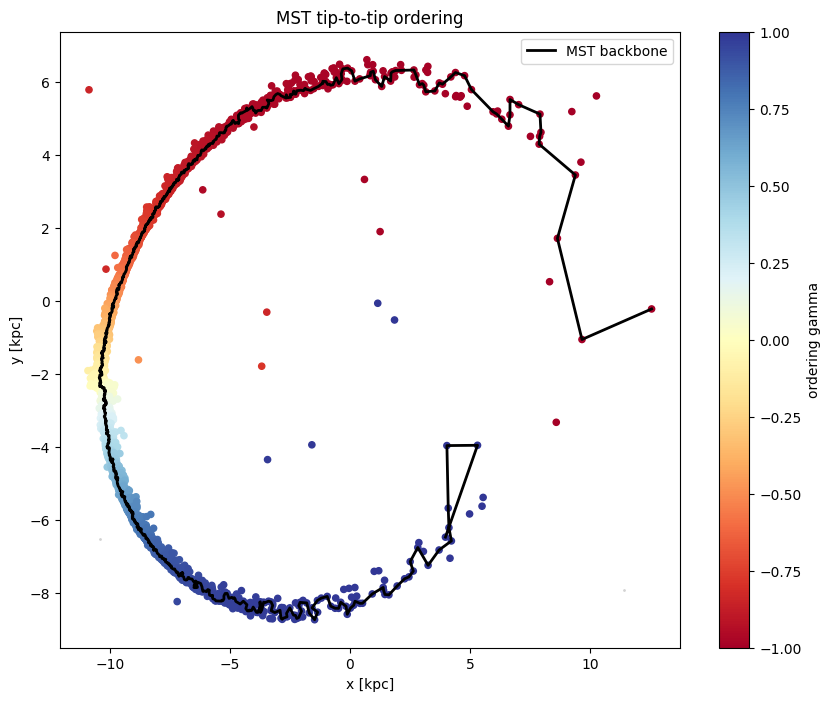

In [8]:
_fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(qs["x"], qs["y"], s=1, c="lightgray")
oq = {k: v[mstresult.ordering] for k, v in mstresult.positions.items()}
timeline = np.linspace(-1, 1, len(mstresult.ordering))
im = ax.scatter(oq["x"], oq["y"], s=20, c=timeline, cmap="RdYlBu")
bx = mstresult.backbone
ax.plot(np.asarray(bx["x"]), np.asarray(bx["y"]), c="k", lw=2, label="MST backbone")
plt.colorbar(im, ax=ax, label="ordering gamma")
ax.set(xlabel="x [kpc]", ylabel="y [kpc]", title="MST tip-to-tip ordering")
ax.legend()
plt.show()

## Autoencoder mean path


In [9]:
key, model_key, train_key = jr.split(key, 3)
normalizer = pcf.nn.StandardScalerNormalizer(qs, ps)
model = pcf.nn.PathAutoencoder.make(
    normalizer, gamma_range=mstresult.gamma_range, key=model_key
)

# Opt in to mixture-model membership (Hogg, Bovy & Lang 2010). The encoder's
# membership becomes a calibrated *posterior* driven by the reconstruction
# residual, so the interlopers the MST threaded in get rejected. See the
# outlier-rejection tutorial and the {doc}`/guides/outliers` guide.
# `membership=None` (the default) recovers the plain classifier behaviour.
membership = pcf.nn.MixtureMembershipConfig(
    sigma_init=0.3,  # guess at the stream half-width (normalised units)
    sigma_ceiling=(1.0, 0.3),  # anneal the width ceiling down
    warmup_frac=0.4,  # fit the track before rejecting anything
)
config = pcf.nn.TrainingConfig(membership=membership)
result, _, losses = pcf.nn.train_autoencoder(
    model, mstresult, config=config, key=train_key
)

Training:   0%|          | 0/800 [00:00<?, ?epoch/s]

Training:   0%|          | 0/100 [00:00<?, ?epoch/s]

Training:   0%|          | 0/200 [00:00<?, ?epoch/s]

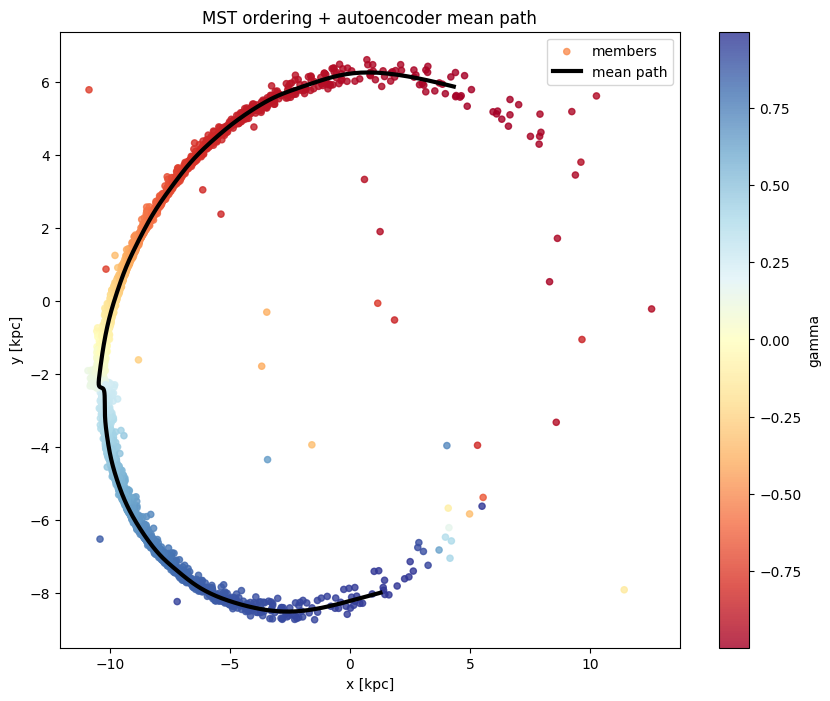

In [10]:
_fig, ax = plt.subplots(figsize=(10, 8))
all_gamma, all_probs = result.model.encode(mstresult.positions, mstresult.velocities)
qs_pred = result(jnp.linspace(*result.gamma_range, 1_000))
im = ax.scatter(
    np.asarray(qs["x"]),
    np.asarray(qs["y"]),
    s=20,
    c=np.asarray(all_gamma),
    cmap="RdYlBu",
    alpha=0.8,
    label="members",
)
ax.plot(
    np.asarray(qs_pred["x"]), np.asarray(qs_pred["y"]), c="k", lw=3, label="mean path"
)
plt.colorbar(im, ax=ax, label="gamma")
ax.set(xlabel="x [kpc]", ylabel="y [kpc]", title="MST ordering + autoencoder mean path")
ax.legend()
plt.show()

## Posterior membership

Because we trained with `MixtureMembershipConfig`, the encoder's membership is a calibrated **posterior**: `posterior_membership` folds the encoder's prior together with how far each star landed from the fitted track. The interlopers -- far from the track -- get a low posterior; the stream keeps a high one. Pass `ws` in the same normalised frame used for training.

A few genuine stars at the sparse, fanned-out tips also dip below 0.5: the tidal tail is genuinely diffuse there, so under a single stream width they sit at the boundary. That is why Hogg et al. recommend keeping the posterior as a *weight* rather than a hard threshold.

In [11]:
# posterior_membership expects ws in the normalised training frame.
qn, pn = result.model.normalizer.transform(qs, ps)
ws = jnp.concatenate([qn, pn], axis=1)
membership_prob = pcf.nn.posterior_membership(result.model, ws)

o = np.asarray(is_outlier)
caught = int((membership_prob[o] < 0.5).sum())
kept = int((membership_prob[~o] >= 0.5).sum())
print(f"interlopers rejected (posterior < 0.5) : {caught}/{int(o.sum())}")
print(f"stream stars kept     (posterior >= 0.5): {kept}/{int((~o).sum())}")

interlopers rejected (posterior < 0.5) : 30/30
stream stars kept     (posterior >= 0.5): 7942/8000


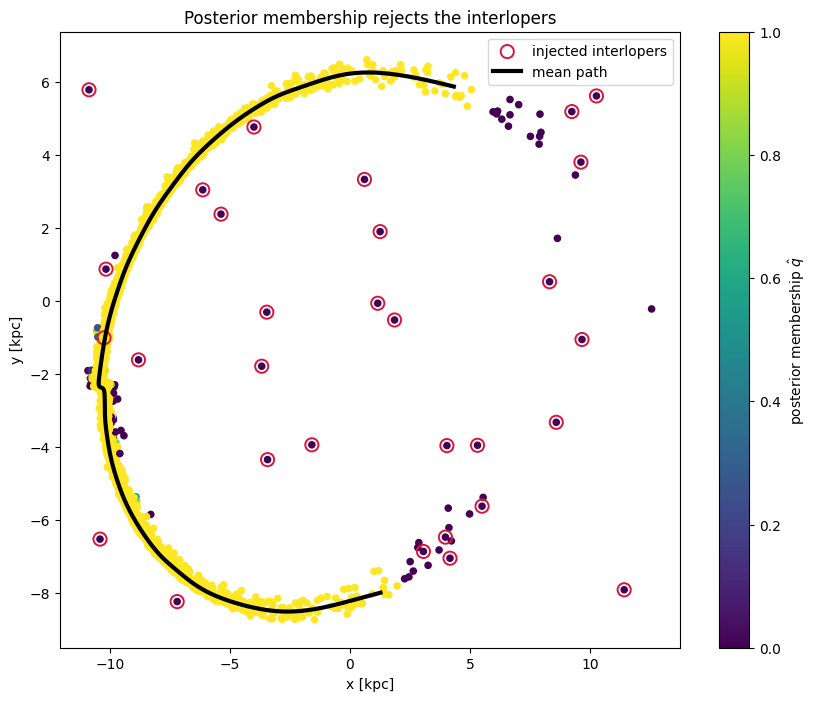

In [12]:
_fig, ax = plt.subplots(figsize=(10, 8))
o = np.asarray(is_outlier)
sc = ax.scatter(
    np.asarray(qs["x"]),
    np.asarray(qs["y"]),
    s=20,
    c=np.asarray(membership_prob),
    cmap="viridis",
    vmin=0,
    vmax=1,
)
ax.scatter(
    np.asarray(qs["x"])[o],
    np.asarray(qs["y"])[o],
    s=90,
    facecolors="none",
    edgecolors="crimson",
    lw=1.4,
    label="injected interlopers",
)
ax.plot(
    np.asarray(qs_pred["x"]), np.asarray(qs_pred["y"]), c="k", lw=3, label="mean path"
)
plt.colorbar(sc, ax=ax, label=r"posterior membership $\hat{q}$")
ax.set(
    xlabel="x [kpc]",
    ylabel="y [kpc]",
    title="Posterior membership rejects the interlopers",
)
ax.legend()
plt.show()